# 03 · Q1: Late deliveries
COO question: "More than half our orders arrive late. Which shipping mode and region should we fix first, and what should we change?"

Scope: shipped orders only (cancelled and fraud orders never shipped).

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

pd.options.display.float_format = '{:,.2f}'.format
FIG = '../reports/figures/'
con = duckdb.connect('../data/dataco.duckdb', read_only=True)

## 6.1 Overall late rate

In [2]:
con.sql("""
    SELECT COUNT(*) AS shipped_orders,
           ROUND(AVG(CASE WHEN is_late THEN 1 ELSE 0 END) * 100, 1) AS late_pct
    FROM orders
    WHERE is_shipped
""").df()

,shipped_orders,late_pct
0,62897,57.30


## 6.2 By shipping mode

In [3]:
mode = con.sql("""
    SELECT shipping_mode,
           COUNT(*) AS orders,
           ROUND(AVG(CASE WHEN is_late THEN 1 ELSE 0 END) * 100, 1) AS late_pct,
           AVG(days_shipping_scheduled) AS promised_days,
           ROUND(AVG(days_shipping_real), 1) AS actual_days
    FROM orders
    WHERE is_shipped
    GROUP BY shipping_mode
    ORDER BY late_pct DESC
""").df()
mode

,shipping_mode,orders,late_pct,promised_days,actual_days
0,First Class,9602,100.00,1.00,2.00
1,Second Class,12256,80.00,2.00,4.00
2,Same Day,3407,48.40,0.00,0.50
3,Standard Class,37632,39.80,4.00,4.00


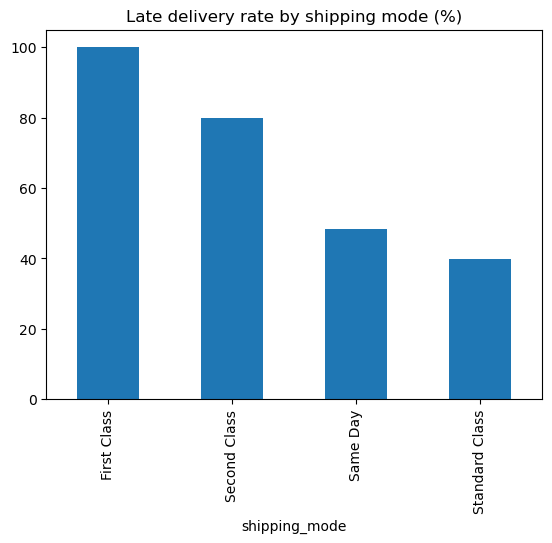

In [4]:
mode.plot.bar(x='shipping_mode', y='late_pct', title='Late delivery rate by shipping mode (%)', legend=False)
plt.savefig(FIG + 'q1_late_by_mode.png', bbox_inches='tight')

## 6.3 By region

In [5]:
region = con.sql("""
    SELECT order_region,
           COUNT(*) AS orders,
           ROUND(AVG(CASE WHEN is_late THEN 1 ELSE 0 END) * 100, 1) AS late_pct,
           RANK() OVER (ORDER BY AVG(CASE WHEN is_late THEN 1 ELSE 0 END) DESC) AS rank
    FROM orders
    WHERE is_shipped
    GROUP BY order_region
    ORDER BY rank
""").df()
region

,order_region,orders,late_pct,rank
0,Central Africa,533,60.00,1
1,East Africa,589,59.10,2
2,South of USA,1280,58.80,3
3,West Asia,1935,58.50,4
4,Western Europe,9563,58.40,5
5,Eastern Europe,1246,58.00,6
6,Southeast Asia,4173,58.00,7
7,South Asia,3219,57.90,8
8,US Center,1852,57.80,9
9,East of USA,2219,57.50,10


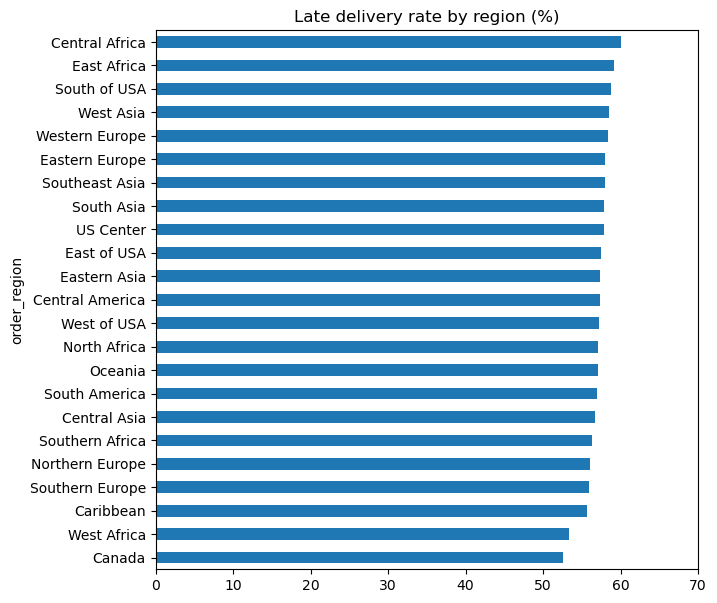

In [6]:
region.sort_values('late_pct').plot.barh(x='order_region', y='late_pct', title='Late delivery rate by region (%)',
                                         legend=False, figsize=(7, 7), xlim=(0, 70))
plt.savefig(FIG + 'q1_late_by_region.png', bbox_inches='tight')

## 6.4 What if promises matched reality?
First Class promise changed from 1 to 2 days; Second Class from 2 to 4 days.

In [7]:
con.sql("""
    SELECT ROUND(AVG(CASE WHEN days_shipping_real > days_shipping_scheduled THEN 1 ELSE 0 END) * 100, 1) AS late_pct_now,
           ROUND(AVG(CASE WHEN days_shipping_real >
                     CASE shipping_mode WHEN 'First Class' THEN 2
                                        WHEN 'Second Class' THEN 4
                                        ELSE days_shipping_scheduled END
                     THEN 1 ELSE 0 END) * 100, 1) AS late_pct_new
    FROM orders
    WHERE is_shipped
""").df()

,late_pct_now,late_pct_new
0,57.30,34.30


## 6.5 Impact in 2017

In [8]:
con.sql("""
    SELECT shipping_mode,
           SUM(CASE WHEN is_late THEN 1 ELSE 0 END) AS late_orders_2017
    FROM orders
    WHERE is_shipped AND order_year = 2017
    GROUP BY shipping_mode
    ORDER BY late_orders_2017 DESC
""").df()

,shipping_mode,late_orders_2017
0,Standard Class,"4,950.00"
1,Second Class,"3,223.00"
2,First Class,"3,146.00"
3,Same Day,606.00


## Answer for the COO

- **Fix First Class first.** It is late on 100% of orders because it always takes 2 days but promises 1.
- **Then Second Class.** It is late on about 80% of orders and is no faster than Standard Class.
- **Region is not the problem.** Every region is 53-60% late.
- **Recommendation:** change the First Class promise to 2 days and Second Class to 4 days (or stop charging extra for it). This would cut the late rate from 57% to about 34%.
- Standard Class is still late 40% of the time because delivery times vary from 2 to 6 days. That needs a review of carriers and warehouses.